In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [22]:
size=1000
# Initialize list to store singular values
singular_values = []

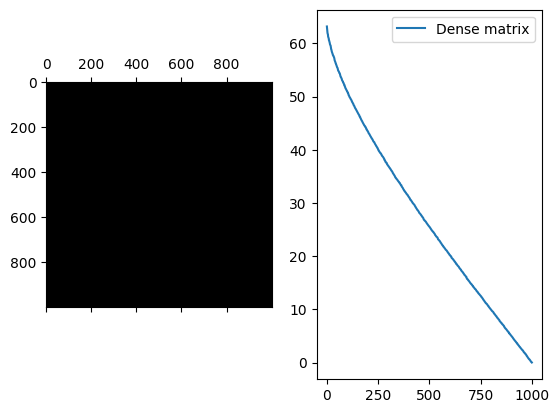

In [23]:
A = np.zeros((size,size))

for i in range(size):
    for j in range(size):
        A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
plt.plot(singular_values[0], label='Dense matrix')
plt.legend()

Smallest 6 singular values of the graph Laplacian: [1.51608736e-01 1.12130383e-01 6.88639396e-02 4.62714606e-02
 2.08259547e-02 1.51962251e-14]


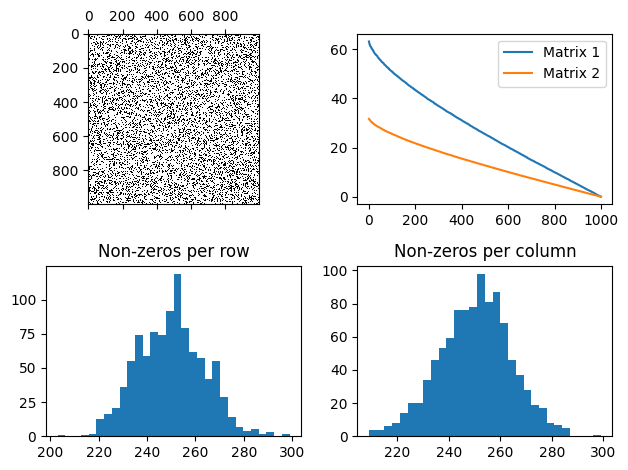

In [24]:
A = np.zeros((size,size))

for i in range(size):
    for j in range(size):
        if np.random.rand() < 0.25:
            A[i,j] = np.random.randn()  

# Count non-zeros per row
row_counts = np.count_nonzero(A, axis=1)
# Count non-zeros per column
col_counts = np.count_nonzero(A, axis=0)

plt.subplot(2,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(2,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()
plt.subplot(2,2,3)
plt.hist(row_counts, bins=30)
plt.title('Non-zeros per row')
plt.subplot(2,2,4)
plt.hist(col_counts, bins=30)
plt.title('Non-zeros per column')
plt.tight_layout()

# Take A and think of it as an adjacency matrix of a graph. What are the singular values of the graph lapalacian?
# The graph Laplacian L is defined as L = D - A, where D is the degree matrix (a diagonal matrix where D[i,i] is the degree of node i) and A is the adjacency matrix. The singular values of the graph Laplacian can be computed using Singular Value Decomposition (SVD) or by computing the eigenvalues of L, since L is symmetric and positive semi-definite.
D = np.diag(np.sum(A, axis=1))
L = D - A
U,E,Vt = np.linalg.svd(L)
print("Smallest 6 singular values of the graph Laplacian:", E[-6:])

Smallest 6 singular values of the graph Laplacian: [5.88027520e-02 1.68817049e-02 2.45327143e-14 1.55298425e-14
 1.39146011e-14 7.69809834e-15]


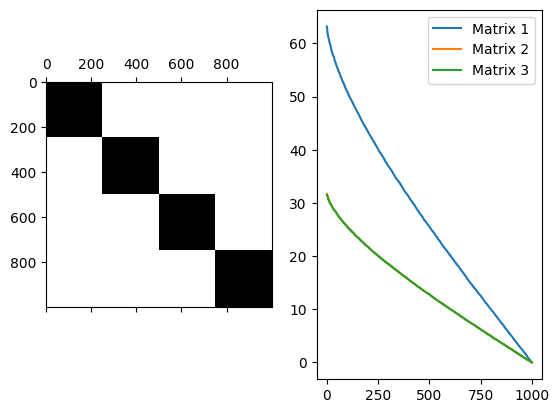

In [25]:
A = np.zeros((size,size))

for i in range(size//4):
    for j in range(size//4):
        A[i,j] = np.random.randn()

for i in range(size//4,size//2):
    for j in range(size//4,size//2):
        A[i,j] = np.random.randn()
  
for i in range(size//2,3*size//4):
    for j in range(size//2,3*size//4):
        A[i,j] = np.random.randn()

for i in range(3*size//4,size):
    for j in range(3*size//4,size):
        A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

# Take A and think of it as an adjacency matrix of a graph. What are the singular values of the graph lapalacian?
# The graph Laplacian L is defined as L = D - A, where D is the degree matrix (a diagonal matrix where D[i,i] is the degree of node i) and A is the adjacency matrix. The singular values of the graph Laplacian can be computed using Singular Value Decomposition (SVD) or by computing the eigenvalues of L, since L is symmetric and positive semi-definite.
D = np.diag(np.sum(A, axis=1))
L = D - A
U,E,Vt = np.linalg.svd(L)
print("Smallest 6 singular values of the graph Laplacian:", E[-6:])




Smallest 6 singular values of the graph Laplacian: [1.58924711e-01 1.16370217e-01 8.81069901e-02 5.86950635e-02
 1.72636641e-02 1.64795715e-14]


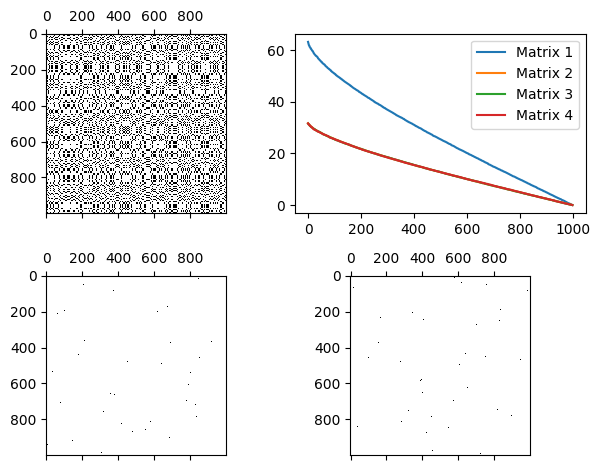

In [26]:
A = np.zeros((size,size))

for i in range(size//4):
    for j in range(size//4):
        A[i,j] = np.random.randn()

for i in range(size//4,size//2):
    for j in range(size//4,size//2):
        A[i,j] = np.random.randn()
  
for i in range(size//2,3*size//4):
    for j in range(size//2,3*size//4):
        A[i,j] = np.random.randn()

for i in range(3*size//4,size):
    for j in range(3*size//4,size):
        A[i,j] = np.random.randn()

# P1 and  P2 are permutation matrices
perm_indices = np.random.permutation(size)
P1 = np.eye(size)[perm_indices]
perm_indices = np.random.permutation(size)
P2 = np.eye(size)[perm_indices]

A = P1 @ A @ P2
plt.subplot(2,2,1)      
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(2,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()
plt.subplot(2,2,3)
plt.spy(P1)
plt.subplot(2,2,4)
plt.spy(P2)
plt.tight_layout()

# Take A and think of it as an adjacency matrix of a graph. What are the singular values of the graph lapalacian?
# The graph Laplacian L is defined as L = D - A, where D is the degree matrix (a diagonal matrix where D[i,i] is the degree of node i) and A is the adjacency matrix. The singular values of the graph Laplacian can be computed using Singular Value Decomposition (SVD) or by computing the eigenvalues of L, since L is symmetric and positive semi-definite.
D = np.diag(np.sum(A, axis=1))
L = D - A
U,E,Vt = np.linalg.svd(L)
print("Smallest 6 singular values of the graph Laplacian:", E[-6:])

In [27]:
# Computer the number of random matrices of size 10x10 with 10x10/4 non-zeros

def count_sizes():
    size = 10
    entries = size*size
    non_zeros = entries//4
    # entries choose non_zeros
    num_combinations = math.comb(entries, non_zeros)
    print(f"Number of ways to choose {non_zeros} positions from {size}x{size} total positions: {num_combinations}")
    print(f"That's approximately 10^{math.log10(num_combinations):.1f}")

    # Computer the number of permutation matrices of size 10x10
    num_permutations = math.factorial(size)
    print(f"Number of permutation matrices of {size} entries: {num_permutations}")
    print(f"That's approximately 10^{math.log10(num_permutations):.1f}")
count_sizes()

Number of ways to choose 25 positions from 10x10 total positions: 242519269720337121015504
That's approximately 10^23.4
Number of permutation matrices of 10 entries: 3628800
That's approximately 10^6.6


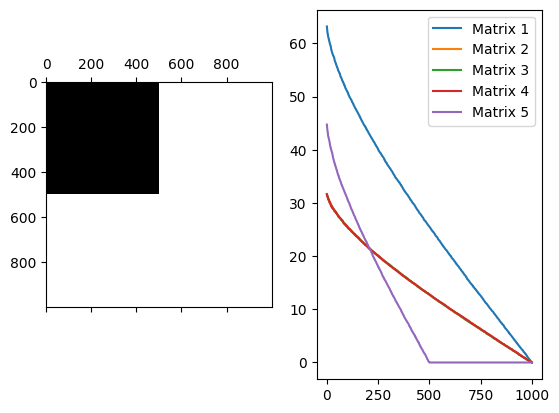

In [28]:
A = np.zeros((size,size))

for i in range(size//2):
    for j in range(size//2):
        A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

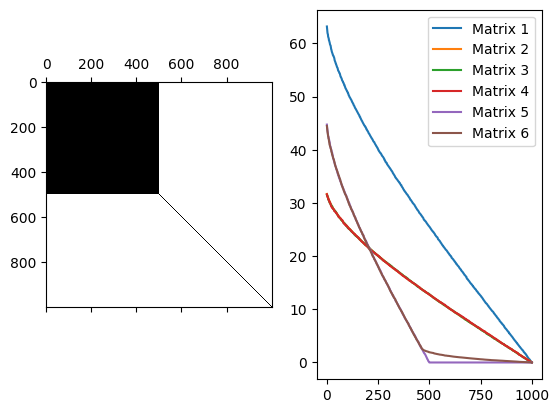

In [29]:
A = np.zeros((size,size))

for i in range(size//2):
    for j in range(size//2):
        A[i,j] = np.random.randn()
for i in range(size//2,size):
    A[i,i] = np.random.randn()


plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

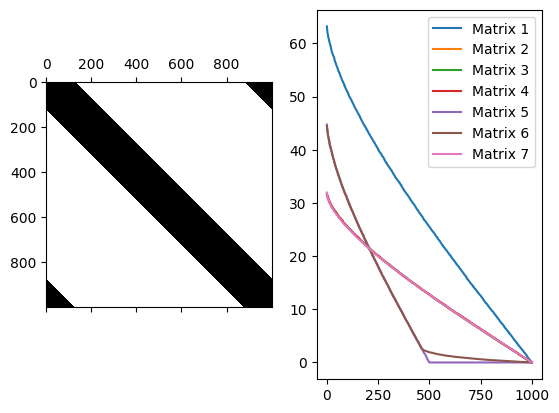

In [30]:
A = np.zeros((size,size))

for i in range(size):
    for j in range(size//4):
            A[i,(i+j-size//8)%size] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

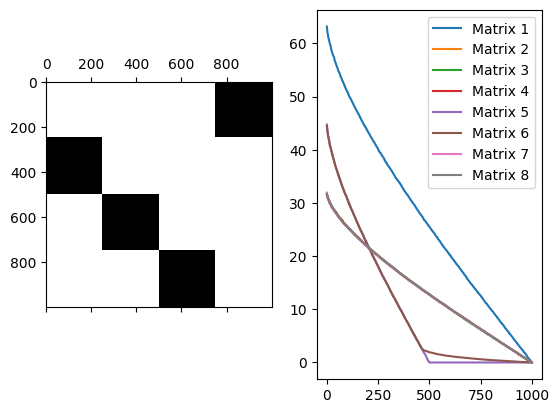

In [31]:
A = np.zeros((size,size))

for i in range(size//4):
    for j in range(3*size//4,size):
        A[i,j] = np.random.randn()

for i in range(size//4,size//2):
    for j in range(size//4):
        A[i,j] = np.random.randn()
  
for i in range(size//2,3*size//4):
    for j in range(size//4,size//2):
        A[i,j] = np.random.randn()

for i in range(3*size//4,size):
    for j in range(size//2,3*size//4):
        A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

# L+S

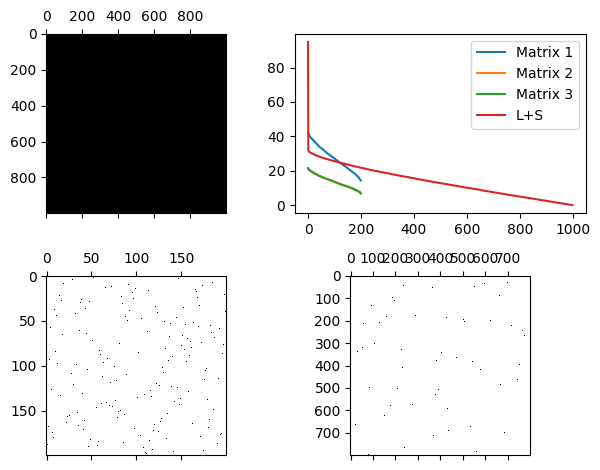

In [42]:
S = np.zeros((size,size))

for i in range(size//4):
    for j in range(size//4):
        S[i,j] = np.random.randn()

for i in range(size//4,size//2):
    for j in range(size//4,size//2):
        S[i,j] = np.random.randn()
  
for i in range(size//2,3*size//4):
    for j in range(size//2,3*size//4):
        S[i,j] = np.random.randn()

for i in range(3*size//4,size):
    for j in range(3*size//4,size):
        S[i,j] = np.random.randn()

U = np.random.randn(size,1)
V = np.random.randn(size,1)

A = S + (U @ V.T)*0.1

plt.subplot(2,2,1)      
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(2,2,2)      
for i, sv in enumerate(singular_values[:3]):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.plot(E, label='L+S')
plt.legend()
plt.subplot(2,2,3)
plt.spy(P1)
plt.subplot(2,2,4)
plt.spy(P2)
plt.tight_layout()

# Let's try some non-square sparse matrices

In [33]:
m = 200
n = 800
# Initialize list to store singular values
singular_values = []

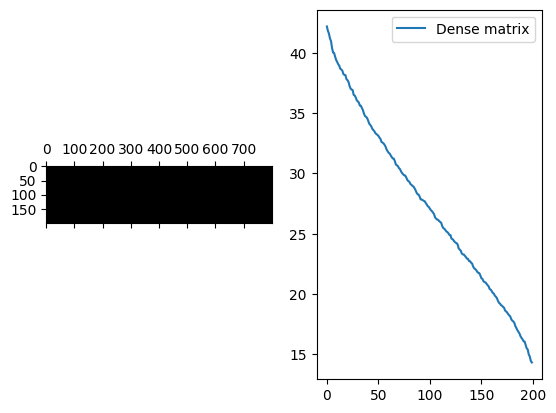

In [34]:
A = np.zeros((m,n))

for i in range(m):
    for j in range(n):
        A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
plt.plot(singular_values[0], label='Dense matrix')
plt.legend()

Text(0.5, 1.0, 'Non-zeros per column')

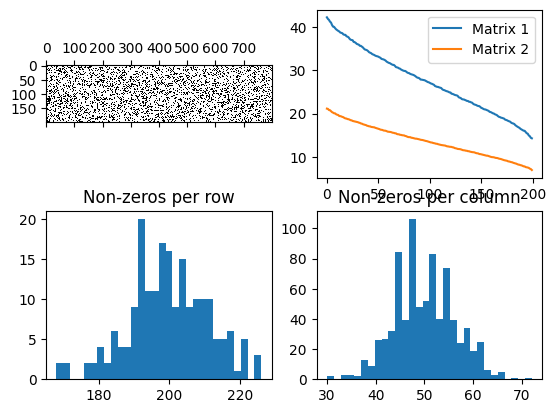

In [35]:
A = np.zeros((m,n))

for i in range(m):
    for j in range(n):
        if np.random.rand() < 0.25:
            A[i,j] = np.random.randn()  

# Count non-zeros per row
row_counts = np.count_nonzero(A, axis=1)
# Count non-zeros per column
col_counts = np.count_nonzero(A, axis=0)

plt.subplot(2,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(2,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()
plt.subplot(2,2,3)
plt.hist(row_counts, bins=30)
plt.title('Non-zeros per row')
plt.subplot(2,2,4)
plt.hist(col_counts, bins=30)
plt.title('Non-zeros per column')

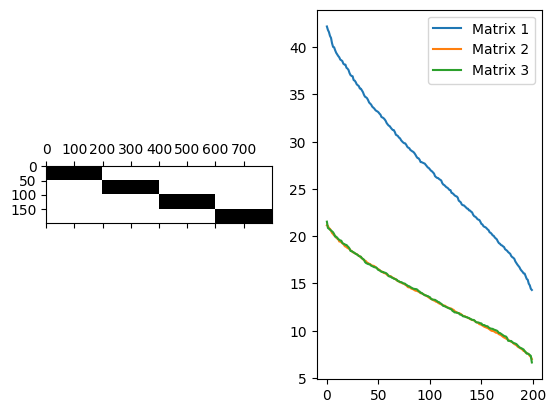

In [36]:
A = np.zeros((m,n))

for i in range(m//4):
    for j in range(n//4):
        A[i,j] = np.random.randn()

for i in range(m//4,m//2):
    for j in range(n//4,n//2):
        A[i,j] = np.random.randn()
  
for i in range(m//2,3*m//4):
    for j in range(n//2,3*n//4):
        A[i,j] = np.random.randn()

for i in range(3*m//4,m):
    for j in range(3*n//4,n):
        A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

Sum of block sizes: 40670, fraction of total matrix: 0.2542


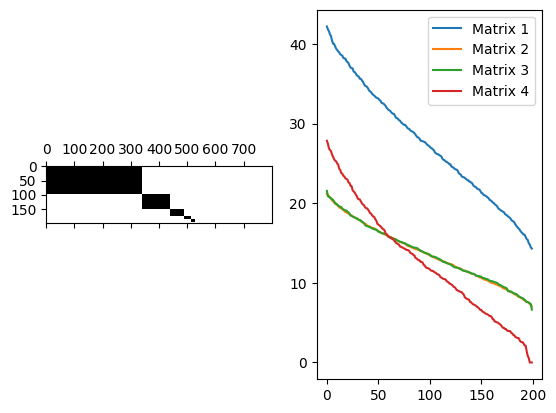

In [37]:
A = np.zeros((m,n))
input_layers = [340,100,50,25,12]
output_layers = [100,50,25,12,10]

# check
assert sum(input_layers) <= n
assert sum(output_layers) <= m

# sum of block sizes
sum_block_size = 0
for k in range(len(input_layers)):
    sum_block_size += input_layers[k] * output_layers[k]
print(f"Sum of block sizes: {sum_block_size}, fraction of total matrix: {sum_block_size/(m*n):.4f}")

for k in range(len(input_layers)):
    start_row = sum(output_layers[:k])
    end_row = start_row + output_layers[k]
    start_col = sum(input_layers[:k])
    end_col = start_col + input_layers[k]
    for i in range(start_row, end_row):
        for j in range(start_col, end_col):
            A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

Sum of block sizes: 39900, fraction of total matrix: 0.2494


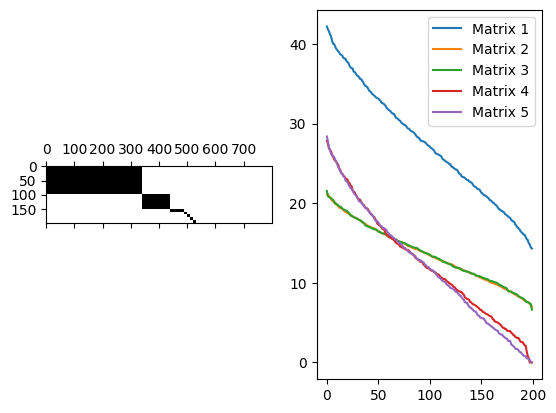

In [38]:
A = np.zeros((m,n))
input_layers = [340,100,50,10,10,10,10]
output_layers = [100,50,10,10,10,10,10]

# check
assert sum(input_layers) <= n
assert sum(output_layers) <= m

# sum of block sizes
sum_block_size = 0
for k in range(len(input_layers)):
    sum_block_size += input_layers[k] * output_layers[k]
print(f"Sum of block sizes: {sum_block_size}, fraction of total matrix: {sum_block_size/(m*n):.4f}")

for k in range(len(input_layers)):
    start_row = sum(output_layers[:k])
    end_row = start_row + output_layers[k]
    start_col = sum(input_layers[:k])
    end_col = start_col + input_layers[k]
    for i in range(start_row, end_row):
        for j in range(start_col, end_col):
            A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

Sum of block sizes: 25900, fraction of total matrix: 0.1619


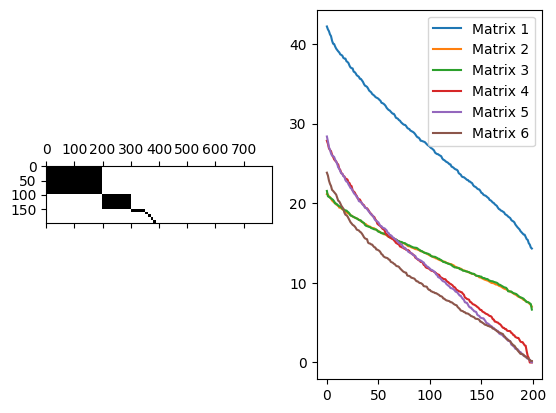

In [39]:
A = np.zeros((m,n))
input_layers = [200,100,50,10,10,10,10]
output_layers = [100,50,10,10,10,10,10]

# check
assert sum(input_layers) <= n
assert sum(output_layers) <= m

# sum of block sizes
sum_block_size = 0
for k in range(len(input_layers)):
    sum_block_size += input_layers[k] * output_layers[k]
print(f"Sum of block sizes: {sum_block_size}, fraction of total matrix: {sum_block_size/(m*n):.4f}")

for k in range(len(input_layers)):
    start_row = sum(output_layers[:k])
    end_row = start_row + output_layers[k]
    start_col = sum(input_layers[:k])
    end_col = start_col + input_layers[k]
    for i in range(start_row, end_row):
        for j in range(start_col, end_col):
            A[i,j] = np.random.randn()

plt.subplot(1,2,1)
plt.spy(A)
U,E,Vt = np.linalg.svd(A)
singular_values.append(E)
plt.subplot(1,2,2)      
for i, sv in enumerate(singular_values):
    plt.plot(sv, label=f'Matrix {i+1}')
plt.legend()

Sum of block sizes: 25900, fraction of total matrix: 0.1619


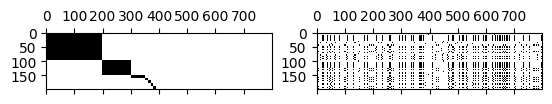

In [40]:
A = np.zeros((m,n))
input_layers = [200,100,50,10,10,10,10]
output_layers = [100,50,10,10,10,10,10]

# check
assert sum(input_layers) <= n
assert sum(output_layers) <= m

# sum of block sizes
sum_block_size = 0
for k in range(len(input_layers)):
    sum_block_size += input_layers[k] * output_layers[k]
print(f"Sum of block sizes: {sum_block_size}, fraction of total matrix: {sum_block_size/(m*n):.4f}")

for k in range(len(input_layers)):
    start_row = sum(output_layers[:k])
    end_row = start_row + output_layers[k]
    start_col = sum(input_layers[:k])
    end_col = start_col + input_layers[k]
    for i in range(start_row, end_row):
        for j in range(start_col, end_col):
            A[i,j] = np.random.randn()


# P1 and  P2 are permutation matrices
perm_indices = np.random.permutation(A.shape[0])
P1 = np.eye(A.shape[0])[perm_indices]
perm_indices = np.random.permutation(A.shape[1])
P2 = np.eye(A.shape[1])[perm_indices]

plt.subplot(1,2,1)
plt.spy(A)
plt.subplot(1,2,2)
plt.spy(P1 @ A @ P2)
